# Import and data extraction

In [1]:
import h5py
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import galpy
from galpy.potential import evaluateDensities
from galpy.orbit import Orbit
from astropy import units  as u
from astropy import constants as c

In [2]:
data = h5py.File('cutout_17.hdf5', 'r')
data.keys()
h = data['Header'].attrs['HubbleParam']

#All attributes
for x in list(data['Header'].attrs):
    print(f'The value for {x} is: {data['Header'].attrs[x]}')


The value for BoxSize is: 35000.0
The value for CutoutID is: 17
The value for CutoutRequest is: PartType0=CenterOfMass,Coordinates,Density,ElectronAbundance,EnergyDissipation,GFM_AGNRadiation,GFM_CoolingRate,GFM_Metallicity,GFM_Metals,GFM_MetalsTagged,GFM_WindDMVelDisp,GFM_WindHostHaloMass,InternalEnergy,Machnumber,MagneticField,MagneticFieldDivergence,Masses,NeutralHydrogenAbundance,ParticleIDs,Potential,StarFormationRate,SubfindDMDensity,SubfindDensity,SubfindHsml,SubfindVelDisp,Velocities+PartType1=Coordinates,ParticleIDs,Potential,SubfindDMDensity,SubfindDensity,SubfindHsml,SubfindVelDisp,Velocities+PartType3=FluidQuantities,ParentID,TracerID+PartType4=BirthPos,BirthVel,Coordinates,GFM_InitialMass,GFM_Metallicity,GFM_Metals,GFM_MetalsTagged,GFM_StellarFormationTime,GFM_StellarPhotometrics,Masses,ParticleIDs,Potential,StellarHsml,SubfindDMDensity,SubfindDensity,SubfindHsml,SubfindVelDisp,Velocities+PartType5=BH_BPressure,BH_CumEgyInjection_QM,BH_CumEgyInjection_RM,BH_CumMassGrowth_Q

In [3]:
#Look at data contained in parttype1
print(data['PartType1'].keys())
print(data['PartType1']["ParticleIDs"])
print(list(data['PartType1']["ParticleIDs"].attrs))


<KeysViewHDF5 ['Coordinates', 'ParticleIDs', 'Potential', 'SubfindDMDensity', 'SubfindDensity', 'SubfindHsml', 'SubfindVelDisp', 'Velocities']>
<HDF5 dataset "ParticleIDs": shape (278904,), type "<u8">
['a_scaling', 'h_scaling', 'length_scaling', 'mass_scaling', 'to_cgs', 'velocity_scaling']


In [4]:
#Extract data
size = data['Header'].attrs['BoxSize']/data['Header'].attrs['HubbleParam'] #units.kpc
center = np.array([size/2, size/2, size/2])
a = data['Header'].attrs['Time'] #scale factor
z = data['Header'].attrs['Redshift'] 
m_dm = data["Header"].attrs["MassTable"][1] * 1e10 / h #units.Msun
N = data["Header"].attrs["NumPart_ThisFile"][1]
coordinates = data['PartType1']["Coordinates"][:]/data['Header'].attrs['HubbleParam'] #units.kpc ->Convert from comoving
velocities = data['PartType1']["Velocities"][:]*np.sqrt(a) #units.km /units.s 
# Gravitational constant (arbitrary units)
G = 4.302e-6  # (kpc * (km/s)^2) / Msun

# Compute potential from data


In [5]:
import numpy as np
from numba import njit, prange

# 1. Build tree -> nodes stored in NumPy arrays to speed up
def build_tree(positions, m_particle, BoxSize):
    """
    Build a tree structure.
    Each node stores:
      - center: cube center in 3D
      - size: cube side length
      - mass: total mass inside this cube
      - com: center of mass of all particles in this cube
      - children: indices of its 8 subcubes (-1 if empty)
    """

    N = len(positions)
    max_nodes = 8 * N  # upper bound -> if all particles are subdivided in single cells
    
    # Arrays for all node properties
    centers = np.zeros((max_nodes, 3))           # node center coordinates
    sizes = np.zeros(max_nodes)                  # cube size
    node_masses = np.zeros(max_nodes)            # total mass in node
    coms = np.zeros((max_nodes, 3))              # node center of mass
    children = -np.ones((max_nodes, 8), dtype=np.int64)  # child indices (-1 = no child)
    
    # Create root node (entire simulation box)
    centers[0] = np.array([BoxSize / 2] * 3)
    sizes[0] = BoxSize
    node_count = 1  # how many nodes we have created
    
    # Stack indicates which node we are building (0= root), how many particles are in that node (now all)
    stack = [(0, np.arange(N))]
    
    while stack:
        #Extract the node index and amount of particles
        node_idx, p_idx = stack.pop() 
        if len(p_idx) == 0: #sanity check that this is not 0
            continue
        
        # Compute total mass and center of mass of this node
        node_masses[node_idx] = len(p_idx) * m_particle
        coms[node_idx] = np.mean(positions[p_idx], axis=0)
        
        # If node contains only one particle → it's a leaf
        if len(p_idx) == 1:
            continue
        
        # Otherwise subdivide the node into 8 subcubes
        child_size = sizes[node_idx] / 2
        half = child_size / 2  # offset from parent center to child center
        
        # Create the 8 children around the node center -> negative and positive wrt to parent center
        offsets = np.array([[dx, dy, dz] for dx in [-1, 1]
                                         for dy in [-1, 1]
                                         for dz in [-1, 1]]) * half
        
        for c in range(8):
            #Create new node & store center and sizes in the array
            child_center = centers[node_idx] + offsets[c]
            centers[node_count] = child_center
            sizes[node_count] = child_size
            
            # Determine which particles belong to this child cube
            cmin = child_center - child_size / 2 #minimum dimensions of the box
            cmax = child_center + child_size / 2 #maximum dimensions of the box
            mask = np.all((positions[p_idx] >= cmin) & (positions[p_idx] < cmax), axis=1) #particle in the box?
            child_particles = p_idx[mask] #particle indexes that are inside the box
            
            # If the child contains particles, link it and add to stack
            if len(child_particles) > 0:
                children[node_idx, c] = node_count
                stack.append((node_count, child_particles))
            
            node_count += 1
    
    # Return all arrays truncated to the actual number of nodes instead of max
    return centers[:node_count], sizes[:node_count], node_masses[:node_count], coms[:node_count], children[:node_count]


# 2. Compute potentials using Barnes-Hut algorithm
@njit(parallel=True) #makes process faster by looping over multiple cores
def compute_potential(positions, m_particle,
                                centers, sizes, node_masses, coms, children,
                                G, theta, BoxSize, eps):
    """
    Compute the gravitational potential for all particles using
    the Barnes–Hut approximation and the pre-built tree.

    Parameters
    ----------
    positions : (N,3) array of particle coordinates
    m_particle: mass of particle (all equal)
    centers, sizes, node_masses, coms, children: tree structure
    G : gravitational constant [kpc (km/s)^2 / Msun]
    theta : opening angle 
    BoxSize : box size 
    eps : softening length
    """

    N = len(positions)
    potentials = np.zeros(N)

    # Loop over all particles in parallel
    for i in prange(N):
        pos = positions[i]
        Phi_total = 0.0

        # Start with the root node (index 0)
        stack = [0]

        while len(stack) > 0:

            #Look at a node from the stack
            node_idx = stack.pop()

            # Skip empty nodes
            if node_masses[node_idx] == 0:
                continue

            # Compute distance vector from particle to node COM
            r = coms[node_idx] - pos

            # Apply periodic boundary conditions (minimum image convention)
            #r = r - BoxSize * np.round(r / BoxSize)

            dist = np.sqrt((r * r).sum()) + eps

            # Skip self-interaction (same particle)
            if dist < eps:
                continue

            # Barnes–Hut criterion:
            # if node is sufficiently far (size/dist < theta) or its a leaf (children == -1)
            # approximate it as a single mass at its COM
            if (sizes[node_idx] / dist) < theta or np.all(children[node_idx] == -1):
                Phi_total += -G * node_masses[node_idx] / dist
            else:
                # Otherwise, open the node and evaluate its children
                for c in children[node_idx]:
                    if c != -1:
                        stack.append(c)

        potentials[i] = Phi_total

    return potentials

In [6]:
theta = 0.5 #common value
eps = 1e-3

#build tree
centers, sizes, node_masses, coms, children = build_tree(coordinates, m_dm, size)

print(f"Tree built: {len(node_masses)} nodes")

# 3. Compute potentials
potentials = compute_potential(
    coordinates,
    m_dm,
    centers,
    sizes,
    node_masses,
    coms,
    children,
    G,
    theta,
    size,
    eps
)


# 4. Output
print("Potentials shape:", potentials.shape)
print("Example potential:", potentials[0])


Tree built: 1085329 nodes
Potentials shape: (278904,)
Example potential: -50401.84125079335


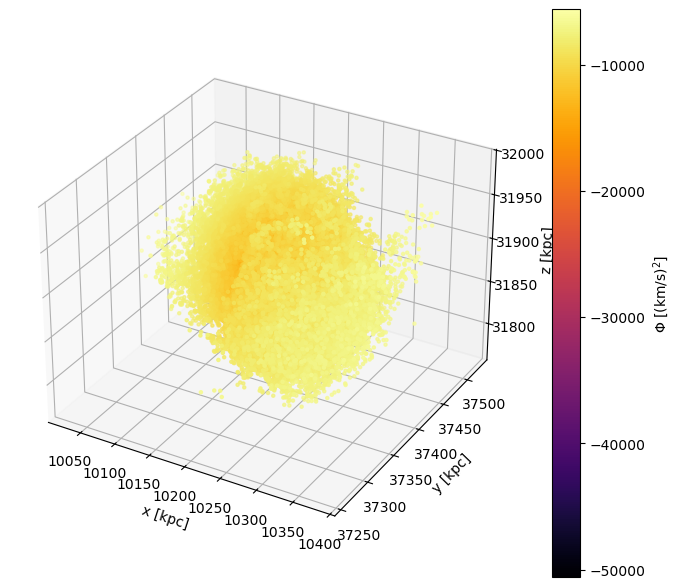

In [7]:
#Plot 3D distribution
fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    coordinates[:,0], coordinates[:,1], coordinates[:,2],
    c=potentials, cmap='inferno', s=5
)
plt.colorbar(sc, label=r'$\Phi$ [(km/s)$^2$]')
ax.set_xlabel("x [kpc]")
ax.set_ylabel("y [kpc]")
ax.set_zlabel("z [kpc]")
plt.tight_layout()
plt.savefig('Potential3D.png')
plt.show()

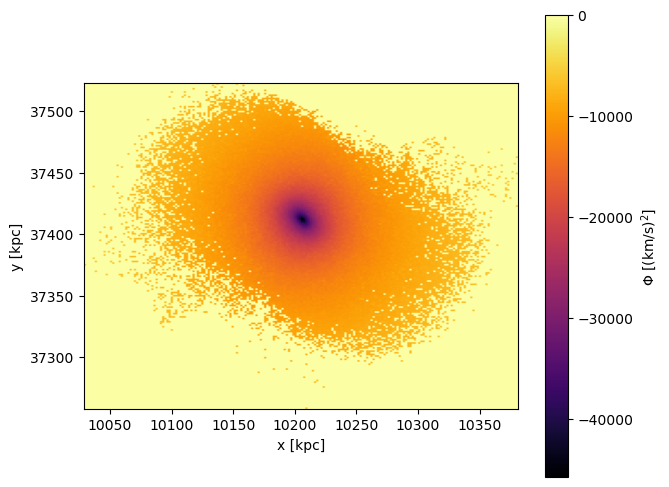

In [8]:
#Not so much to see so project everything on x and y axis and smoothen in bins 
x = coordinates[:,0]
y = coordinates[:,1]
z = coordinates[:,2]

xmin, xmax = x.min(), x.max()
ymin, ymax = y.min(), y.max()
zmin, zmax = z.min(), z.max()

bins = 200
H, xedges, yedges = np.histogram2d(x, y,
                                   bins=bins, range = ((xmin, xmax), (ymin, ymax)), weights=potentials)
counts, _, _ = np.histogram2d(x,y, range=((xmin, xmax), (ymin, ymax)),
                              bins=bins)
phi_map = H / np.maximum(counts, 1)  # avoid divide by zero

plt.figure(figsize= (7,6))
plt.imshow(phi_map.T, origin='lower',
           extent=(xmin, xmax, ymin, ymax),
           cmap='inferno')
plt.colorbar(label=r'$\Phi$ [(km/s)$^2$]')
plt.xlabel("x [kpc]")
plt.ylabel("y [kpc]")
plt.savefig('Projectedpotxy.png')
plt.show()


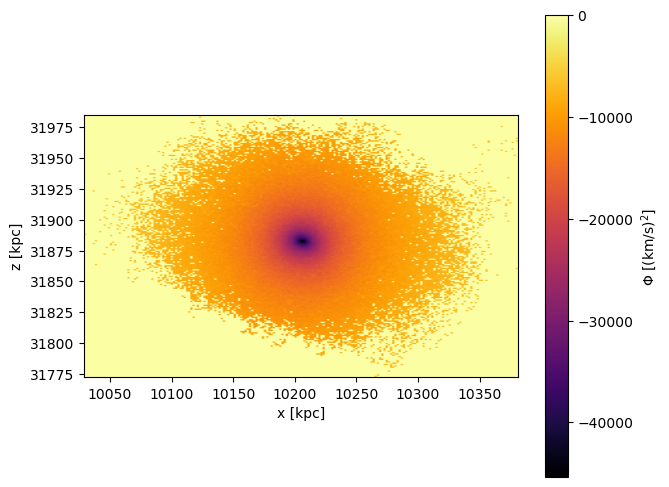

In [9]:

bins = 200
H, xedges, yedges = np.histogram2d(x, z,
                                   bins=bins, range = ((xmin, xmax), (zmin, zmax)), weights=potentials)
counts, _, _ = np.histogram2d(x,z, range=((xmin, xmax), (zmin, zmax)),
                              bins=bins)
phi_map = H / np.maximum(counts, 1)  # avoid divide by zero
plt.figure(figsize= (7,6))
plt.imshow(phi_map.T, origin='lower',
           extent=(xmin, xmax, zmin, zmax),
           cmap='inferno')
plt.colorbar(label=r'$\Phi$ [(km/s)$^2$]')
plt.xlabel("x [kpc]")
plt.ylabel("z [kpc]")
plt.savefig('Projectedpotxz.png')
plt.show()


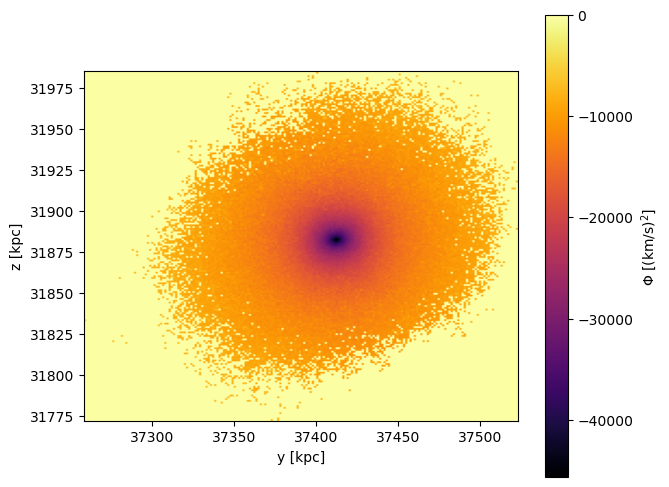

In [10]:

bins = 200
H, xedges, yedges = np.histogram2d(y, z,
                                   bins=bins, range = ((ymin, ymax), (zmin, zmax)), weights=potentials)
counts, _, _ = np.histogram2d(y,z, range=((ymin, ymax), (zmin, zmax)),
                              bins=bins)
phi_map = H / np.maximum(counts, 1)  # avoid divide by zero

plt.figure(figsize= (7,6))
plt.imshow(phi_map.T, origin='lower',
           extent=(ymin, ymax, zmin, zmax),
           cmap='inferno')
plt.colorbar(label=r'$\Phi$ [(km/s)$^2$]')
plt.xlabel("y [kpc]")
plt.ylabel("z [kpc]")
plt.savefig('Projectedpotyz.png')
plt.show()


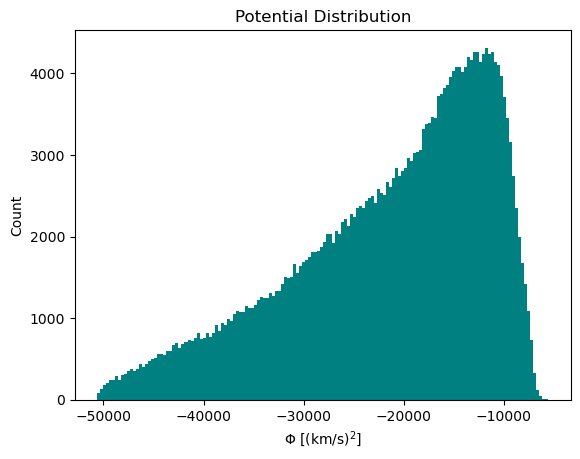

In [11]:
#potential distribution
plt.hist(potentials, bins=150, color='teal')
plt.xlabel(r'$\Phi$ [(km/s)$^2$]')
plt.ylabel("Count")
plt.title("Potential Distribution")
plt.show()

# Part 2) Compute density profile $\rho(r)$ from particle data

## a) Compute and plot the spherical density function

In [12]:
center_of_mass = np.mean(coordinates, axis=0) #Naieve, does not give the most bound particle
print(center_of_mass)

#Most bound particle
i = np.argmin(potentials)
pot = np.min(potentials)
most_bound = coordinates[i]
print(most_bound)


[10206.77606909 37411.1265164  31882.36022063]
[10205.99425338 37411.93283495 31882.18198569]


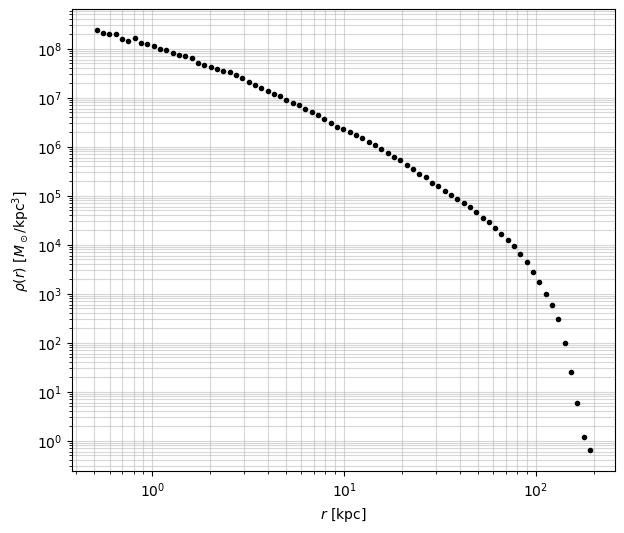

In [13]:
center_of_mass = np.mean(coordinates, axis=0)
radius_particles = np.linalg.norm(coordinates - most_bound, axis=1) #compute the radius of each particle (distance to most bound particle)


# Log-spaced bins
N_bins = 80
r_min = np.percentile(radius_particles, 0.1)     # avoid r=0 bin
r_max = np.max(radius_particles)
r_bins = np.logspace(np.log10(r_min), np.log10(r_max), N_bins)

particles_per_bin, _ = np.histogram(radius_particles, bins = r_bins) #array with the radius of each particle in N_bins bins
shell_volume = (4/3)*np.pi*(r_bins[1:]**3 - r_bins[:-1]**3) #volume of shell (r_i+1 - r_i)
rho_data = particles_per_bin*m_dm/shell_volume
r_mid = np.sqrt(r_bins[1:] * r_bins[:-1])

# Poisson uncertainty
sigma_rho = m_dm * np.sqrt(np.maximum(particles_per_bin, 1)) / shell_volume
sigma_log10 = (1/np.log(10)) * sigma_rho / np.maximum(rho_data, 1e-300)

import matplotlib.pyplot as plt
plt.figure(figsize= (7,6))
plt.loglog(r_mid, rho_data, "k.", label="Data")
plt.xlabel(r"$r$ [kpc]")
plt.ylabel(r"$\rho(r)$ [$M_\odot$/kpc$^3$]")
plt.grid(which = 'both', alpha = 0.5)
plt.savefig('densitydata.png')
plt.show()

## b) Fit the density with a function that can be used in galpy

A list with the spherical potentials in Galpy can be found __[here](https://docs.galpy.org/en/latest/reference/potential.html)__. We will try to fit the Plummer potential first.

Plummer best-fit params: [19.26531168] chi2=1647.12
Hernquist best-fit params: [15.73543932] chi2=476.88
C:\Users\grego\AppData\Local\Temp\ipykernel_30484\190341719.py:42: RuntimeWarning: invalid value encountered in log10
  return np.log10(func(r, *p))

NFW best-fit params: [3.96223131e+07 5.13492391e+00] chi2=475.26


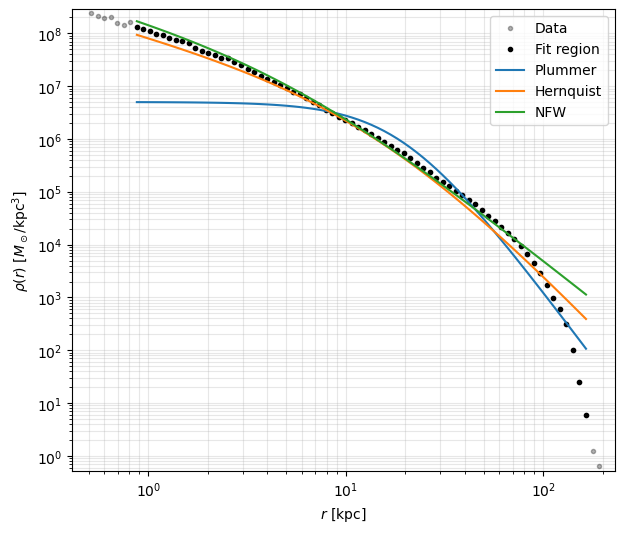

In [14]:
from scipy.optimize import curve_fit
from galpy.potential import PlummerPotential

M = m_dm*N
softening_length = 0.288 #scale below which gravity is smoothed to avoid divergences.
                         #is reported on TNG-50 for z <= 1

#Define the densities we want to fit
def rho_plummer(r, a):
    """Plummer density: M = total mass, a = scale"""
    return (3.0 * M) / (4.0 * np.pi * a**3) * (1.0 + (r**2 / a**2))**(-2.5)

def rho_hernquist(r, a):
    """Hernquist density"""
    return (M / (2.0 * np.pi)) * (a / (r * (r + a)**3))

def rho_nfw(r, rho_0, rs):
    """NFW parametrized by rho0 and scale radius rs_scale"""
    x = r/rs
    return rho_0 / (x * (1 + x)**2)


models = [
    ("Plummer", rho_plummer, [1.0]),
    ("Hernquist", rho_hernquist, [1.0]),
    ("NFW", rho_nfw, [1e7, 1.0]),
]

# Fit interval:  strip zeros / remove outer 10%/soften core
mask = (rho_data > 0) & (r_mid < 0.9 * r_mid.max()) & (r_mid > 3*softening_length)
rfit = r_mid[mask]
rhfit = rho_data[mask]
sigma_fit = sigma_log10[mask]

plt.figure(figsize=(7,6))
plt.loglog(r_mid, rho_data, "k.", label="Data", alpha = 0.3)
plt.loglog(rfit, rhfit, "k. ", label = 'Fit region') #higlight fitted region

for name, func, p0 in models:
    # Fit in log‐space -> log10(rho), and compare to log10(rho_data)
    def fitfunc(r, *p):
        return np.log10(func(r, *p))
    
    popt, _ = curve_fit(fitfunc, rfit, np.log10(rhfit), sigma = sigma_fit, p0=p0, maxfev=20000)
    
    # Plot fitted curve
    plt.loglog(rfit, func(rfit, *popt), label=f"{name}")

    #Calculate reduced chi2 in logspace
    y_model  = np.log10(func(rfit, *popt))
    residual = np.log10(rhfit) - y_model
    chi2 = np.sum((residual/sigma_fit)**2)
    dof = len(rfit) - len(popt)
    reducedchi2 = chi2 / max(dof, 1)
    

    print(f"{name} best-fit params: {popt}", f"chi2={reducedchi2:.2f}")


plt.xlim(min(r_mid)*0.8, max(r_mid)*1.2)
plt.ylim(min(rho_data)*0.8, max(rho_data)*1.2)

plt.xlabel(r"$r$ [kpc]")
plt.ylabel(r"$\rho(r)$ [$M_\odot / \mathrm{kpc}^3$]")
plt.legend()
plt.grid(which= 'both', alpha=0.3)
plt.savefig('densityfit.png')
plt.show()

# Part 3) Use the best fit do do an analysis

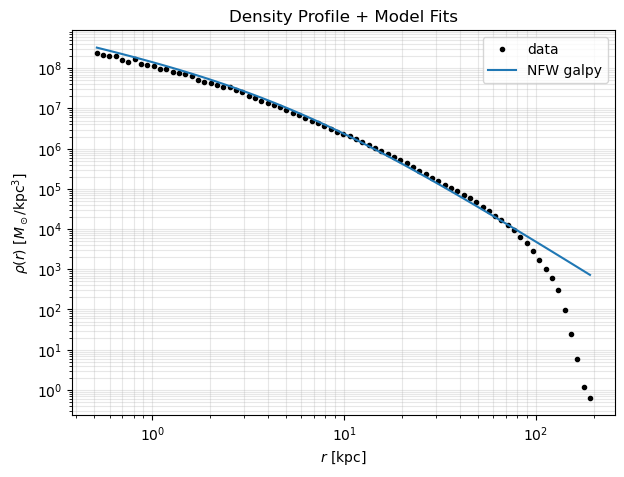

In [43]:
#Best fit model is NFW model with rho_0=3.96223131e+07, rs=5.13492391, amp=4*np.pi*rho_0_best*rs_best**3 (galpy vs book)
rho_0_best = 3.96223131e+07*(u.Msun/u.kpc**3)
rs_best = 5.13492391*u.kpc
amp = (4*np.pi*rho_0_best*rs_best**3).to(u.Msun)
r_mid = r_mid*u.kpc

NFW_potential = galpy.potential.NFWPotential(amp= amp, a = rs_best)
rho_model = NFW_potential.dens(r_mid, 0*u.kpc).to(u.Msun/u.kpc**3).value  # Msun/kpc^3

#check to see if the Galpy density corresponds to what we fitted
plt.figure(figsize=(7,5))

plt.loglog(r_mid, rho_data, "k.", label="data")
plt.loglog(r_mid, rho_model, label="NFW galpy")

plt.xlabel(r"$r$ [kpc]")
plt.ylabel(r"$\rho(r)$ [$M_\odot / \mathrm{kpc}^3$]")
plt.title("Density Profile + Model Fits")
plt.legend()
plt.grid(which= 'both', alpha=0.3)
plt.show()

Next we will look at different dynamical properties due to the potential

## a) Orbits

In [132]:
#1) Orbits
#choose a random points in the halo to simulate the orbit
index = 10000
x_point, y_point, z_point = (coordinates[index] - most_bound)*u.kpc
vx_point, vy_point, vz_point = velocities[index]*(u.km/u.s)

vx_point -= np.mean(velocities[:, 0]) * u.km/u.s
vy_point -= np.mean(velocities[:, 1]) * u.km/u.s
vz_point -= np.mean(velocities[:, 2]) * u.km/u.s

#change to cylindrical coordinates
R_point = np.sqrt(x_point**2+y_point**2).to(u.kpc)
phi_point = np.arctan2(y_point, x_point).to(u.rad)
v_R_point = ((x_point*vx_point + y_point*vy_point)/R_point).to(u.km/u.s)
v_T_point = ((x_point*vy_point - y_point*vx_point)/R_point).to(u.km/u.s)

orbit = Orbit([R_point, v_R_point, v_T_point, z_point, vz_point, phi_point])

ts = np.linspace(0 , 1000 , 50000)* u.Myr
orbit.integrate(ts, NFW_potential)

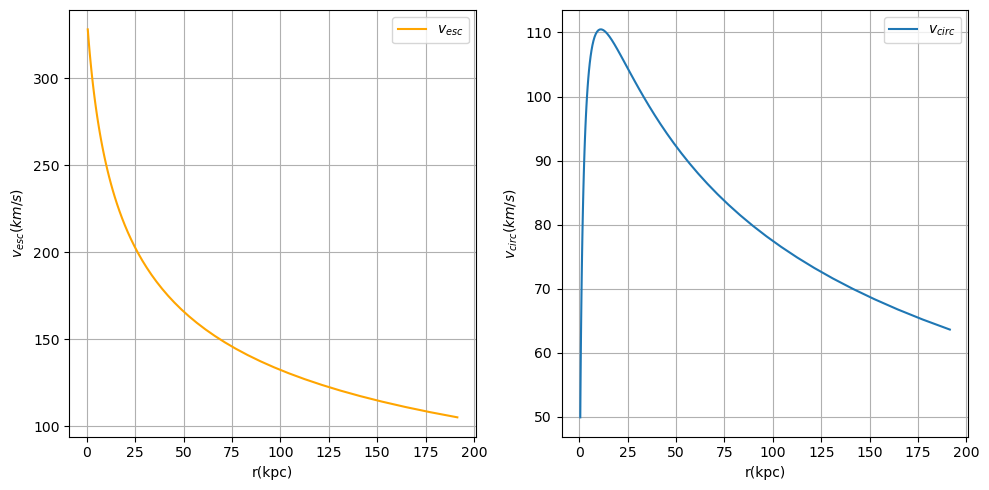

In [133]:
#Plot the escape and circular velocities
v_escape = NFW_potential.vesc(r_mid).to(u.km/u.s)
v_circular = NFW_potential.vcirc(r_mid).to(u.km/u.s)

fig, axs = plt.subplots(1,2, figsize=(10,5))

axs[0].plot(r_mid, v_escape, label=r"$v_{esc}$", color = 'orange')
axs[0].set_xlabel("r(kpc)")
axs[0].set_ylabel(r"$v_{esc}(km/s)$")
axs[0].legend()
axs[0].grid()

axs[1].plot(r_mid, v_circular, label=r"$v_{circ}$")
axs[1].set_xlabel("r(kpc)")
axs[1].set_ylabel(r"$v_{circ}(km/s)$")
axs[1].legend()
axs[1].grid()

fig.tight_layout()
plt.show()

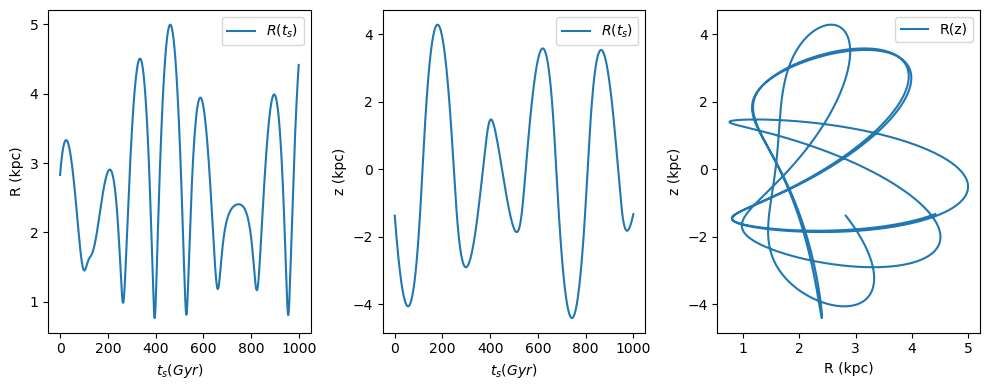

In [134]:
R = orbit.R(ts) #cylindrical radius, not radial!
z = orbit.z(ts)

#plot the orbits
fig, axs = plt.subplots(1,3, figsize=(10,4))

axs[0].plot(ts, R, label = r'$R(t_s)$')
axs[0].set_xlabel(r'$t_s (Gyr)$')
axs[0].set_ylabel('R (kpc)')
axs[0].legend(loc='upper right')

axs[1].plot(ts, z, label = r'$R(t_s)$')
axs[1].set_xlabel(r'$t_s (Gyr)$')
axs[1].set_ylabel('z (kpc)')
axs[1].legend(loc='upper right')

axs[2].plot(R, z, label = 'R(z)')
axs[2].set_xlabel('R (kpc)')
axs[2].set_ylabel('z (kpc)')
axs[2].legend(loc='upper right')

fig.tight_layout()  # <-- call it on the figure, not the axes
plt.show()

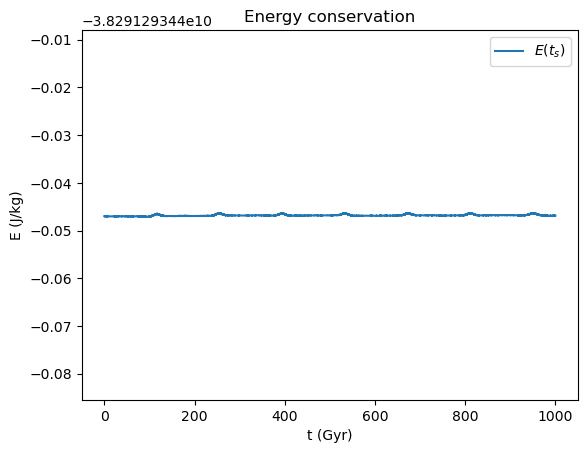

In [135]:
#check energy conservation

plt.plot(ts, orbit.E(ts).to(u.J/u.kg), label=r"$E(t_s)$")
plt.xlabel('t (Gyr)')
plt.ylabel('E (J/kg)')
plt.title("Energy conservation")
plt.legend()
plt.show()

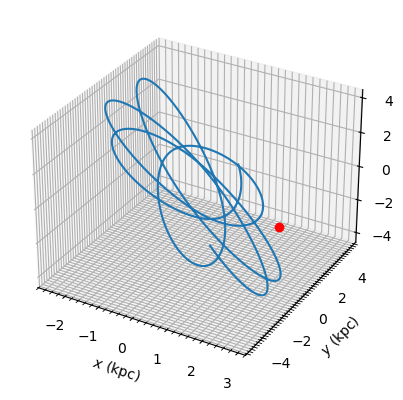

In [136]:
#also chech the vertical direction
orbit.plot3d()
plt.plot([orbit.R().to_value()],[orbit.z().to_value()],'ro')
plt.show()

In [137]:
orbit.animate3d()

In [128]:
#other dynamical properties

#1) Eccentricity
e = orbit.e()

#2) max_z
z_max = orbit.zmax()

#3) Pericenter/Apocenter
pericenter = orbit.rperi()
apocenter = orbit.rap()

#4) periods
azimuthal_period = orbit.Tp()
radial_period = orbit.Tr()

#5) frequencies (2pi/periods)
azimuthal_frequency = orbit.Op()
vertical_frequency = orbit.Oz()
radial_frequency = orbit.Or()

#6) Angular momentum
angular_momentum = orbit.L(ts)

#7) azimuthal angle
azimuthal_angle = orbit.phi(ts)

#8) polar angle
polar_angle = orbit.theta(ts)


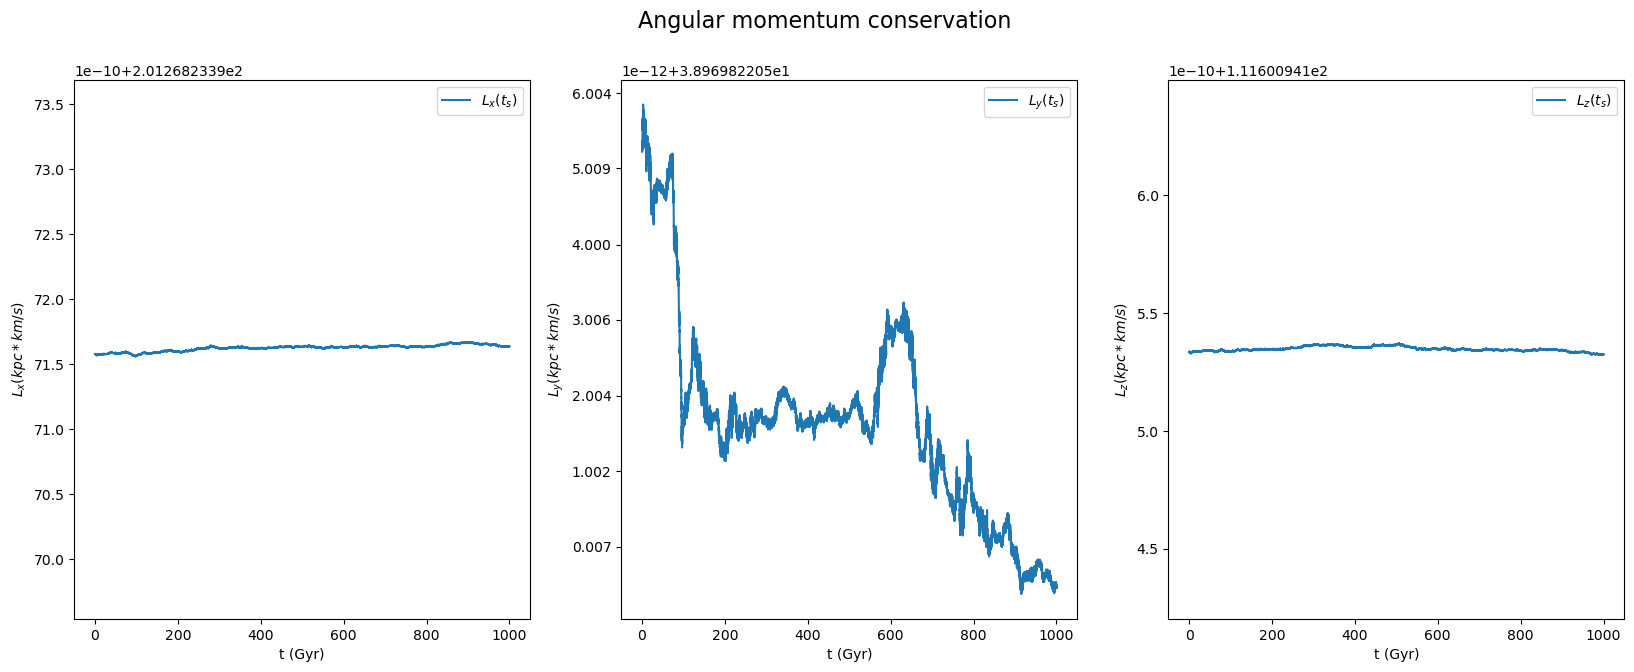

In [115]:
#check angular momentum conservation
xyz = ['x', 'y', 'z']
fig, axs = plt.subplots(1,3, figsize=(20,7))

for i in range(3):
    axs[i].plot(ts, orbit.L(ts).to(u.kpc*u.km/u.s)[:, i], label=rf"$L_{xyz[i]}(t_s)$")
    axs[i].set_xlabel('t (Gyr)')
    axs[i].set_ylabel(rf'$L_{xyz[i]}(kpc*km/s)$')
    axs[i].legend()

fig.suptitle('Angular momentum conservation', fontsize=16)
plt.show()

# Part 4) Rotation curves 

For a spherical system, the rotation velocity at radius $r$ is estimated directly from the velocity as:
\begin{equation}
v_c(r) = \sqrt{\langle v^2_{\phi}\rangle},
\end{equation} 
where $v_{\phi}$ is the tangential velocity around the halo center.



In [22]:
from galpy.potential import HernquistPotential


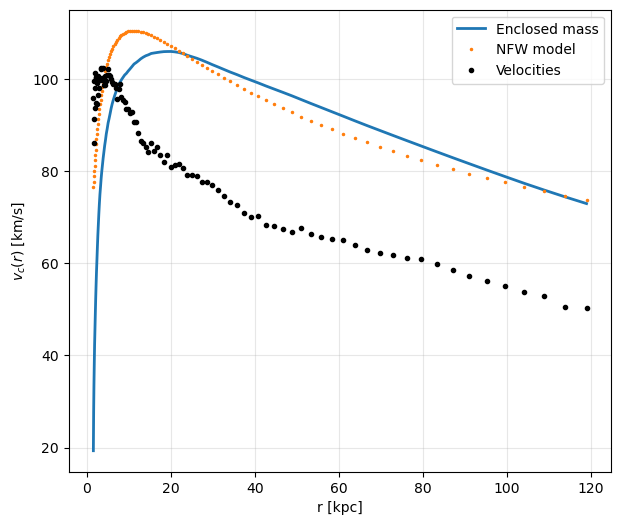

In [131]:
#shift coordinate system around center
pos = coordinates-most_bound
# subtract bulk halo motion
vel = velocities - np.mean(velocities, axis=0)  

#take distance from center (most bound particle)
r = radius_particles


# Remove r = 0 particles (center particle)
mask_nonzero = r > 0
pos = pos[mask_nonzero]
vel = vel[mask_nonzero]
r  = r[mask_nonzero]

# Unit radial vectors
r_hat = pos / r[:, None]

# Radial velocity component v_r
v_r = np.sum(vel * r_hat, axis=1)

# Tangential velocity squared v_t^2 = v^2 - v_r^2
v2 = np.sum(vel**2, axis=1)
v_t2 = v2 - v_r**2


#Put r in log-bins
N_bins = 100
r_min = np.percentile(r, 1)    # ignore exact zero
r_max = np.percentile(r, 99)   # trim extreme outliers
r_bins = np.logspace(np.log10(r_min), np.log10(r_max), N_bins)
r_mid_mask = np.sqrt(r_bins[1:] * r_bins[:-1])


#Assigns each particle to a radial bin
bin_idx = np.digitize(r, r_bins) - 1

# Keep only valid bin assignments (bugfix -> gave errors)
valid = (bin_idx >= 0) & (bin_idx < N_bins-1)
bin_idx = bin_idx[valid]
v_t2    = v_t2[valid]

#Compute v_t^2 and counts  inside each bin
v_t2_sum = np.bincount(bin_idx, weights=v_t2, minlength=N_bins-1)[:N_bins-1]
counts   = np.bincount(bin_idx, minlength=N_bins-1)[:N_bins-1]

# Compute circular velocity per bin as average
vc_vel = np.full(N_bins-1, np.nan)
vc_vel= np.sqrt(v_t2_sum / counts)

#Calculate vcirc with galpy
M = m_dm*N

vc_galpy = NFW_potential.vcirc(r_mid_mask*u.kpc).to(u.km/u.s).value 
v_circular = NFW_potential.vcirc(r_mid_mask*u.kpc).to(u.km/u.s)


#Calculate enclosed mass 

cumulative_counts = np.cumsum(counts)          # particles inside r_mid
M_enc = m_dm * cumulative_counts               # Msun

# Circular velocity from enclosed mass
vc_mass = np.sqrt(G * M_enc / r_mid_mask)  # km/s

# Plot comparison
plt.figure(figsize=(7,6))
plt.plot(r_mid_mask, vc_mass, '-', lw=2, label='Enclosed mass')
plt.plot(r_mid_mask, vc_galpy, '.', ms=3, label='NFW model')
plt.plot(r_mid_mask, vc_vel, 'k.', label="Velocities") 

plt.xlabel("r [kpc]")
plt.ylabel(r"$v_c(r)$ [km/s]")
plt.grid(alpha=0.3)
plt.legend()
plt.savefig('rotationcurves.png')
plt.show()